# Modello ADAF del disco di accrescimento
Uso programma di Chiara Righi

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv  # per il calcolo della funzione di bessel

# ==========================================================
# COSTANTI
# ==========================================================
ALFA = 0.3  # parametro di viscosità=quanto efficientemente il momento angolare viene trasportato verso l’esterno
RMIN = 3.0 # rmin in unità di Schwarzschild
RMAX = 1000.0 # rmax in unità di Schwarzschild
DELTA = 0.0 # 

C1 = 0.5 # coefficiente per la velocità radiale
C3 = 0.3 # coefficiente per la temperatura ionica
TNORM = 1.68e-10 # temperatura normale per la conversione in unità di energia (k_B*T in erg)

In [221]:
# ==========================================================
# FUNZIONI MATEMATICHE
# ==========================================================
def bessk(n, x):  # funzione di Bessel K di ordine n e argomento x, serve per le formule relativistiche degli elettroni termici
    return kv(n, x)

def g(teta):   # funzione g che entra nel termine di riscaldamento del plasma relativistico
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

In [222]:
# ==========================================================
# SISTEMA NON LINEARE
# ==========================================================

def temperat(y, mdot, m, beta):  
    #funzione che definisce il sistema di equazioni non lineari da risolvere per trovare la temperatura degli elettroni, la temperatura ionica e la densità del plasma
    # INPUT= y: array con le variabili da risolvere [teta, xm], mdot: tasso di accrescimento in unità di Eddington, m: massa del buco nero in unità di massa solare, beta: rapporto tra pressione magnetica e pressione totale
    # OUTPUT= array con i residui delle tre equazioni da risolvere

    ff =  y[2]**2 # frazione di energia che va agli elettroni
    xm = 1e3 * y[1]**2 # densità del plasma in unità di cm^-3
    teta = y[0]**2   # temperatura degli elettroni in unità di energia (k_B*T in erg)

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # --- Heating ---  #calcolo la potenza totale che scalda elettroni
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # --- Synchrotron --- 
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)  #frequenza picco sincrotronico
    psinc = (  #potenza emessa dal sincrotrone
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5)

    # --- Compton Inverso ---
    abig = 1 + 4*teta + 16*teta**2  #fattore di amplificazione energetica 
    tau = 23.87 * mdot   #profondità ottica del plasma
    alfac = -np.log(tau) / np.log(abig)  #indice spettrale 
    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1   
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa    #potenza emessa dal Compton inverso

    # --- Brems ---
    if teta < 1:  #bremsstrahlung non relativistico
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:  #bremsstrahlung relativistico
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)
    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2  #potenza emessa dal bremsstrahlung

    # --- Equazioni ---
    f1 = q - psinc - pcomp - pbrems  #equazione di bilancio energetico: il calore guadagnato dagli elettroni deve essere uguale all’energia che perdono irradiando 
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q   # frazione di energia che va agli ioni: il calore guadagnato dagli ioni deve essere uguale a quello perso per trasferimento agli elettroni
    vv = xm**(1/3)  # velocità radiale in unità di c, che dipende dalla densità del plasma
    f3 = (  #equazione di conservazione della massa: la velocità radiale deve essere coerente con la densità del plasma e il tasso di accrescimento
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta)))

    return [f1, f3, f2]  


In [223]:
# ==========================================================
# SPETTRO
# ==========================================================

def spectrum(te, f, xm, m, mdot, beta, savefile=None):

    numin = 1e10 #copro da radio
    numax = 1e21 #arrivo a raggi gamma
    num = 100
    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te #torno da temperatura in energia a temperatura in unità di energia (k_B*T in erg)

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)
    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4)) #logaritmo della frequenza di picco del sincrotrone
    lnucmax = np.log10(te) + 10.796  #cutoff massimo della componente di Compton, che dipende dalla temperatura degli elettroni

    # coefficiente sinc
    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te))

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):
        # ---------------- SYNCHROTRON ----------------
        if lnu[i] < lnup:  #la componente di sincrotrone è significativa solo per frequenze inferiori alla frequenza di picco
            lls[i] = (  # logaritmo della luminosità spettrale in quella approssimazione
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i])
        else:
            lls[i] = 0.0
        # ---------------- COMPTON ----------------
        if lnu[i] > lnup:  #la componente di Compton è significativa solo per frequenze superiori alla frequenza di picco del sincrotrone
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = 0.0
        # ---------------- BREMS ----------------
        if teta < 1: 
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)
        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2))
        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b


    flux = 10**lls + 10**llc + 10**llb  #somma totale delle tre componenti
    y = lnu + np.log10(flux)  #logaritmo della luminosità spettrale totale, che è quello che vogliamo plottare

# QUI CAMBIO RISPETTO AL CODICE ORIGINALE DI RIGHI, non mi faccio plottare le singole componenti, ma solo la somma totale
    if savefile is not None:
        np.savetxt(savefile, np.column_stack([lnu, y]))
        print(f"File salvato: {savefile}")
    return lnu, y, lls, llc, llb

In [224]:
# ==========================================================
# specdata
# ==========================================================

def specdata(m, mdot, beta, savefile=None, verbose=True):  #verbose serve per stampare i parametri di input, se verbose è True, altrimenti no

    if verbose:
        print(f"m = {m}")
        print(f"mdot = {mdot}")
        print(f"beta = {beta}")

    y0 = [0.5, 1.0, 0.99]  # valori iniziali per teta, xm e f (in radice quadrata)
    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)  #risolvo il sistema di equazioni non lineari per trovare teta, xm e f
    if not sol.success:
        print("Non converge")
    y = sol.x
    teta = y[0]**2  
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    if verbose:
        print("\n=== OUTPUT ===")
        print("te   =", te)  
        print("xm   =", xm)
        print("f    =", f)

    lnu, spettro_tot, lls, llc, llb = spectrum(te, f, xm, m, mdot, beta, savefile=savefile)

    return {
        "lnu": lnu,
        "log_nuFnu": spettro_tot,
        "log_sync": lls,
        "log_compton": llc,
        "log_brems": llb,
        "te": te,
        "xm": xm,
        "f": f,
        "m": m,
        "mdot": mdot,
        "beta": beta}

In [225]:
# ==========================================================
# PLOT DI PIU' SCENARI
# ==========================================================

def plot_scenari_righi(scenari):
    
    plt.figure(figsize=(8, 6))

    for sc in scenari:
        risultato = specdata(
            m=sc["m"],
            mdot=sc["mdot"],
            beta=sc["beta"],
            savefile=sc.get("savefile", None),
            verbose=sc.get("verbose", False))

        plt.plot(
            risultato["lnu"],
            risultato["log_nuFnu"],
            label=sc.get("label", f'm={sc["m"]:.1e}, mdot={sc["mdot"]:.1e}, beta={sc["beta"]}'),
            color=sc.get("color", None),
            linewidth=2)

    plt.xlabel("log nu [Hz]")
    plt.ylabel("log nu*Lnu [erg/s]")
    plt.xlim(10, 21)
    plt.ylim(34,43)
    plt.legend(loc="lower left")
    plt.show()

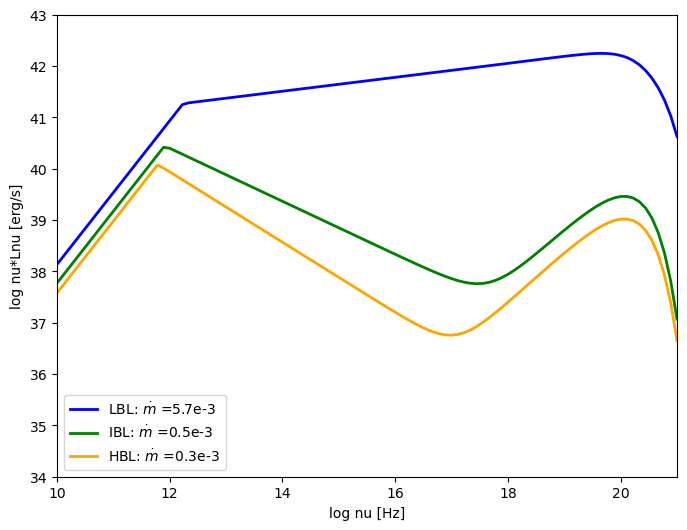

In [226]:
# ==========================================================
# DATI PRESI DA ARTICOLO CHIARA RIGHI
# ==========================================================
scenari_righi = [
    {
        "m": 1e9,
        "mdot": 5.7e-3,
        "beta": 0.5,
        "color": "blue",
        "label": r"LBL: $\dot m$ =5.7e-3"},
    {
        "m": 1e9,
        "mdot": 0.5e-3,
        "beta": 0.5,
        "color": "green",
        "label": r"IBL: $\dot m$ =0.5e-3"},
    {
        "m": 1e9,
        "mdot": 0.3e-3,
        "beta": 0.5,
        "color": "orange",
        "label": r"HBL: $\dot m$ =0.3e-3"}
]

plot_scenari_righi(scenari_righi) 

OSS: HBL ha picco sincrotrone di poco troppo alto e ventre troppo alto, picco IC ok  
 IBL ha picco sincrotrone troppo alto, ventre ok, picco IC ok  
 LBL ha picco sincrotrone ok, picco IC un po' altino

In [227]:
# ==========================================================
# PLOT DI PIU' SCENARI
# ==========================================================
def plot_scenari_mahadevan(scenari):

    plt.figure(figsize=(8, 8))

    for sc in scenari:
        risultato = specdata(
            m=sc["m"],
            mdot=sc["mdot"],
            beta=sc["beta"],
            savefile=sc.get("savefile", None),
            verbose=sc.get("verbose", False)
        )

        plt.plot(
            risultato["lnu"],
            risultato["log_nuFnu"],
            label=sc.get("label", f'm={sc["m"]:.1e}, mdot={sc["mdot"]:.1e}, beta={sc["beta"]}'),
            color=sc.get("color", None),
            linewidth=2
        )

    plt.xlabel("log nu [Hz]", fontdict={"fontsize": 14})
    plt.ylabel("log nu*Lnu [erg/s]", fontdict={"fontsize": 14})
    plt.ylim(35, 43)
    plt.legend(loc="lower left")
    plt.show()

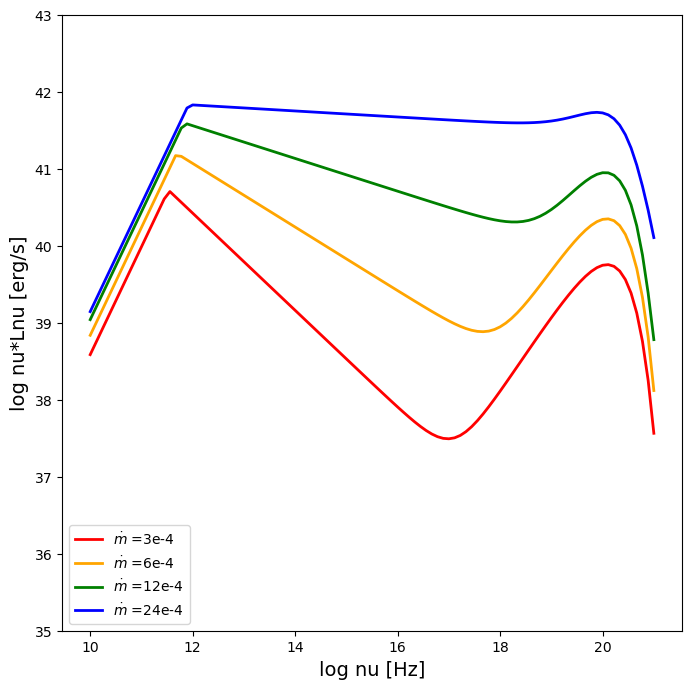

In [228]:
# ==========================================================
# DATI PRESI DA ARTICOLO MAHADEVAN
# ==========================================================
scenari_mahadevan = [
    {
        "m": 5e9,
        "mdot": 3e-4,
        "beta": 0.5,
        "color": "red",
        "label":  r"$\dot m$ =3e-4" },
    {
        "m": 5e9,
        "mdot": 6e-4,
        "beta": 0.5,
        "color": "orange",
        "label": r"$\dot m$ =6e-4" },
    {
        "m": 5e9,
        "mdot": 12e-4,
        "beta": 0.5,
        "color": "green",
        "label": r"$\dot m$ =12e-4" },
    {
        "m": 5e9,
        "mdot": 24e-4,
        "beta": 0.5,
        "color": "blue",
        "label": r"$\dot m$ =24e-4" }
]

plot_scenari_mahadevan(scenari_mahadevan)

OSS: forse curva blu ha picco sincrotrone troppo alto, dovrebbe essere della stessa altezza del picco di IC, se non più basso

In [229]:
# ==========================================================
# FREQUENZE DI IONIZZAZIONE
# ==========================================================
nu_ion_dict = {
    "Ha":    4.60e14,
    "Hb":    6.20e14,
    "Hg":    6.91e14,
    "Hd":    7.37e14,
    "MgII":  3.63e15,
    "CIII":  1.315e16,
    "CIV":   1.158e16}


# ==========================================================
# CALCOLO DI L_ion = integral_{nu_ion}^{nu_max} L_nu dnu
# ==========================================================
def calcola_Lion(risultato, nu_ion):
    """
    Calcola:
        L_ion = \int_{nu_ion}^{nu_max} L_nu dnu
    dove il dizionario 'risultato' è l'output di specdata().
    ATTENZIONE:
    risultato["log_nuFnu"] = log10(nu * Lnu)
    quindi:
        log10(Lnu) = log10(nuLnu) - log10(nu)
    """

    lnu = risultato["lnu"]                 # log10(nu)
    log_nuLnu = risultato["log_nuFnu"]     # log10(nu * Lnu)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu

    # selezione della parte sopra la soglia di ionizzazione
    mask = nu >= nu_ion

    if np.sum(mask) < 2:
        return 0.0

    nu_sel = nu[mask]
    Lnu_sel = Lnu[mask]

    Lion = np.trapezoid(Lnu_sel, nu_sel)
    return Lion


# ==========================================================
# CALCOLO DI L_ion PER TUTTE LE SOGLIE
# ==========================================================

def calcola_tutte_le_Lion(risultato, nu_ion_dict):
    """
    Restituisce un dizionario con L_ion calcolata per ciascuna frequenza di soglia.
    """
    Lion_dict = {}

    for linea, nu_ion in nu_ion_dict.items():
        Lion_dict[linea] = calcola_Lion(risultato, nu_ion)

    return Lion_dict

<>:18: SyntaxWarning: invalid escape sequence '\i'
<>:18: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_59671/1283273345.py:18: SyntaxWarning: invalid escape sequence '\i'
  """


In [230]:
ris = specdata(1e9, 5.7e-3, 0.5, verbose=True)
Lion_dict = calcola_tutte_le_Lion(ris, nu_ion_dict)

print("\n=== L_ion per le diverse soglie di ionizzazione ===")
for linea, Lion in Lion_dict.items():
    print(f"{linea:6s}   nu_ion = {nu_ion_dict[linea]:.3e} Hz   L_ion = {Lion:.3e}")

m = 1000000000.0
mdot = 0.0057
beta = 0.5

=== OUTPUT ===
te   = 3793614474.704159
xm   = 1178.3413966349508
f    = 0.9404787352796324

=== L_ion per le diverse soglie di ionizzazione ===
Ha       nu_ion = 4.600e+14 Hz   L_ion = 1.421e+43
Hb       nu_ion = 6.200e+14 Hz   L_ion = 1.400e+43
Hg       nu_ion = 6.910e+14 Hz   L_ion = 1.400e+43
Hd       nu_ion = 7.370e+14 Hz   L_ion = 1.400e+43
MgII     nu_ion = 3.630e+15 Hz   L_ion = 1.312e+43
CIII     nu_ion = 1.315e+16 Hz   L_ion = 1.236e+43
CIV      nu_ion = 1.158e+16 Hz   L_ion = 1.252e+43


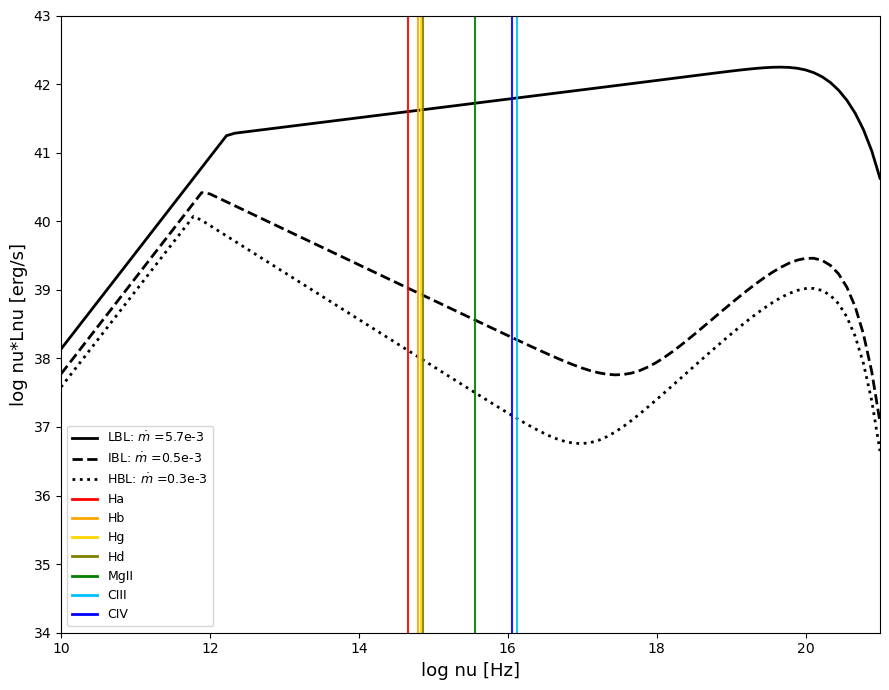

In [231]:
from matplotlib.lines import Line2D

def plot_adaf_con_ionizzazione(scenari, nu_ion_dict):

    plt.figure(figsize=(9, 7))
    line_styles = ["-", "--", ":"]
    # colori per linee di ionizzazione
    colori_ion = {
        "Ha": "red",
        "Hb": "orange",
        "Hg": "gold",
        "Hd": "olive",
        "MgII": "green",
        "CIII": "deepskyblue",
        "CIV": "blue"
    }

    legend_elements = []

    # =========================
    # spettri ADAF
    # =========================
    for i, sc in enumerate(scenari):
        risultato = specdata(
            m=sc["m"],
            mdot=sc["mdot"],
            beta=sc["beta"],
            verbose=False)

        plt.plot(
            risultato["lnu"],
            risultato["log_nuFnu"],
            color="black",
            linestyle=line_styles[i],
            linewidth=2)

        # legenda LBL / IBL / HBL
        legend_elements.append(
            Line2D([0], [0],
                   color="black",
                   linestyle=line_styles[i],
                   linewidth=2,
                   label=sc["label"]))

    # =========================
    # righe verticali ionizzazione
    # =========================
    for linea, nu_ion in nu_ion_dict.items():
        log_nu = np.log10(nu_ion)

        plt.axvline(
            log_nu,
            color=colori_ion.get(linea, "gray"),
            linestyle="-",
            linewidth=1.5,
            alpha=0.9)

        # aggiungo alla legenda
        legend_elements.append(
            Line2D([0], [0],
                   color=colori_ion.get(linea, "gray"),
                   linestyle="-",
                   linewidth=2,
                   label=linea))

    # =========================
    # grafico
    # =========================
    plt.xlabel("log nu [Hz]", fontsize=13)
    plt.ylabel("log nu*Lnu [erg/s]", fontsize=13)
    plt.xlim(10, 21)
    plt.ylim(34, 43)

    # legenda dentro il grafico (senza titolo)
    plt.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=9,
        frameon=True)

    plt.tight_layout()
    plt.show()

plot_adaf_con_ionizzazione(scenari_righi, nu_ion_dict)